<a href="https://colab.research.google.com/github/orcorsetti/MCD-Austral/blob/main/Regresion%20Avanzada/Regresion%20Lineal%20Simple/RA26_1_Clase1_CO_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Regresión Lineal Simple - Clase 1

**Autora original:** Cecilia Oliva  
**Fecha de conversión a Python:** 17/03/2026

Este notebook es una adaptación de un archivo **R Markdown** a **Python**.  
Se mantuvo la estructura conceptual original, pero se reemplazó el código en R por alternativas en Python usando principalmente:

- `pandas` para lectura y manipulación de datos
- `matplotlib` y `seaborn` para gráficos
- `scipy.stats` para tests estadísticos
- `statsmodels` para modelos lineales y diagnóstico

> **Importante:** este notebook asume que los archivos `IMCinfantil.xlsx` y `gorriones.xlsx` están en la misma carpeta que este `.ipynb`.


In [11]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


SyntaxError: invalid syntax (635406214.py, line 8)

## Correlación e introducción al modelo lineal

## Ejemplo 1: Índice de masa corporal infantil


Realizamos los diagramas de dispersión de las variables del dataset **IMCinfantil.xlsx**.


In [3]:
# Replace this URL with the raw URL of your Excel file on GitHub
github_excel_url = 'https://github.com/orcorsetti/MCD-Austral/raw/main/Regresion%20Avanzada/Regresion%20Lineal%20Simple/IMCinfantil.xlsx'

try:
    df_github = pd.read_excel(github_excel_url)
    print("Excel file loaded successfully from GitHub!")
    display(df_github.head())
    IMCinfantil = df_github

    print(IMCinfantil.shape)
    display(IMCinfantil.head())

    base_ninios = IMCinfantil[["EDAD", "PESO", "TALLA", "IMC", "CC"]].copy()
    base_ninios.head()
except Exception as e:
    print(f"Error loading Excel file from GitHub: {e}")
    print("Please ensure the URL is correct and points to the raw Excel file.")
    # Assign an empty DataFrame or handle the error appropriately if loading fails
    IMCinfantil = pd.DataFrame() # Assign an empty DataFrame to avoid NameError if the try block fails


Excel file loaded successfully from GitHub!


,PACIENTE,EDAD,SEXO,PESO,TALLA,IMC,PIMC,CC,CatPeso
0,1,7,M,24.4000,1.2000,16.9444,7.9700,54,N
1,2,7,M,23.6000,1.2000,16.3889,72.7200,52,N
2,3,8,M,47.0000,1.4000,23.9796,97.0800,76,OB
3,4,7,F,24.0000,1.2000,16.6667,83.8800,63,N
4,5,7,M,23.9000,1.2000,16.5972,45.8500,56,N


(150, 9)


,PACIENTE,EDAD,SEXO,PESO,TALLA,IMC,PIMC,CC,CatPeso
0,1,7,M,24.4000,1.2000,16.9444,7.9700,54,N
1,2,7,M,23.6000,1.2000,16.3889,72.7200,52,N
2,3,8,M,47.0000,1.4000,23.9796,97.0800,76,OB
3,4,7,F,24.0000,1.2000,16.6667,83.8800,63,N
4,5,7,M,23.9000,1.2000,16.5972,45.8500,56,N


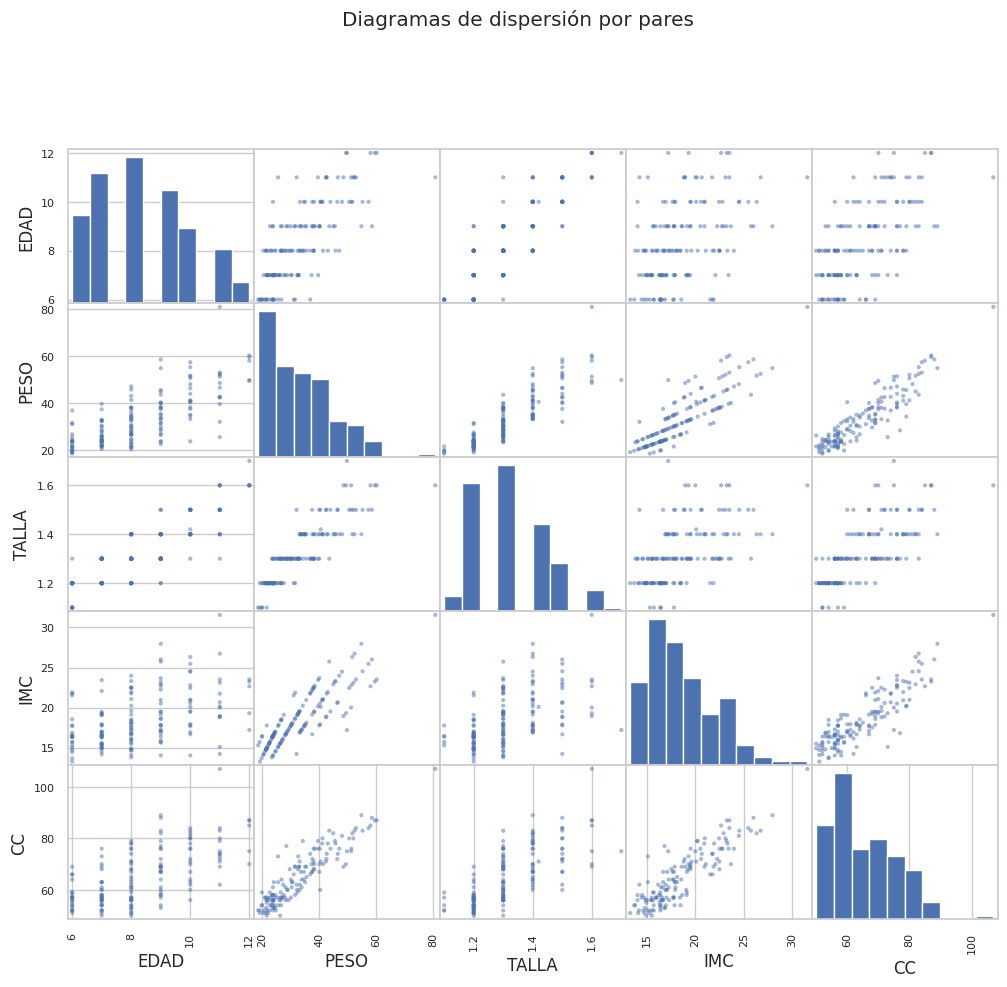

In [4]:

# Matriz de dispersión
pd.plotting.scatter_matrix(base_ninios, figsize=(12, 10), diagonal='hist')
plt.suptitle("Diagramas de dispersión por pares", y=1.02)
plt.show()


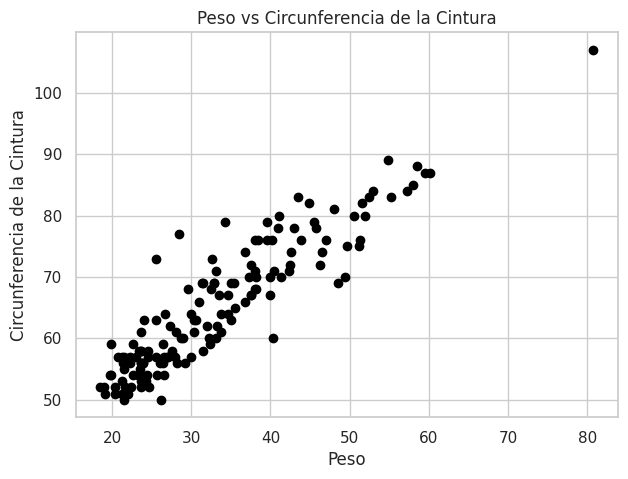

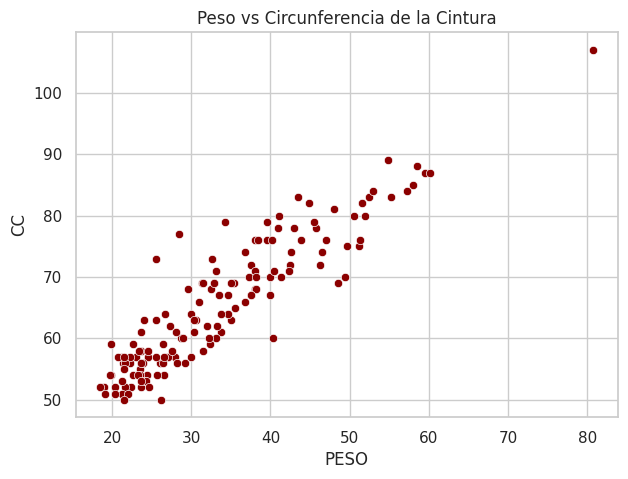

In [5]:

# Diagrama de dispersión sencillo
plt.figure(figsize=(7, 5))
plt.scatter(IMCinfantil["PESO"], IMCinfantil["CC"], color="black")
plt.xlabel("Peso")
plt.ylabel("Circunferencia de la Cintura")
plt.title("Peso vs Circunferencia de la Cintura")
plt.show()

# Diagrama con seaborn
plt.figure(figsize=(7, 5))
sns.scatterplot(data=IMCinfantil, x="PESO", y="CC", color="darkred")
plt.title("Peso vs Circunferencia de la Cintura")
plt.show()


### Boxplots y medidas resumen

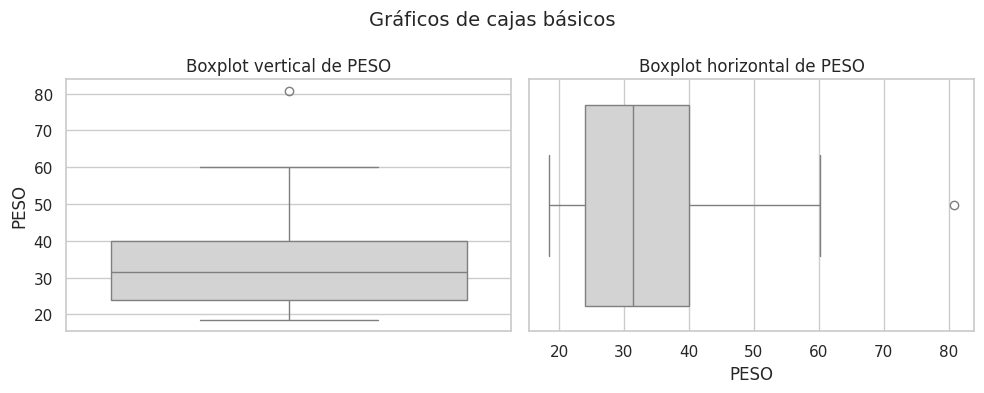

In [6]:

# Boxplots básicos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=IMCinfantil["PESO"], ax=axes[0], color="lightgray")
axes[0].set_title("Boxplot vertical de PESO")

sns.boxplot(x=IMCinfantil["PESO"], ax=axes[1], color="lightgray")
axes[1].set_title("Boxplot horizontal de PESO")

fig.suptitle("Gráficos de cajas básicos", fontsize=14)
plt.tight_layout()
plt.show()


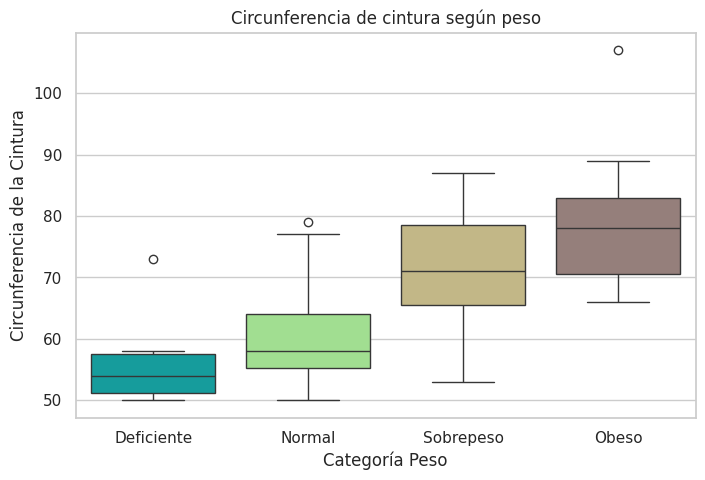

In [7]:

IMCinf = IMCinfantil.copy()

# Cambio de etiquetas para CatPeso
mapa_peso = {
    "D": "Deficiente",
    "N": "Normal",
    "OB": "Obeso",
    "SO": "Sobrepeso"
}

IMCinf["CatPeso"] = IMCinf["CatPeso"].replace(mapa_peso)
orden_cat = ["Deficiente", "Normal", "Sobrepeso", "Obeso"]
IMCinf["CatPeso"] = pd.Categorical(IMCinf["CatPeso"], categories=orden_cat, ordered=True)

plt.figure(figsize=(8, 5))
sns.boxplot(data=IMCinf, x="CatPeso", y="CC", palette="terrain")
plt.title("Circunferencia de cintura según peso")
plt.xlabel("Categoría Peso")
plt.ylabel("Circunferencia de la Cintura")
plt.show()


In [8]:

# Medidas resumen para PESO
print(IMCinfantil["PESO"].describe())
print("Media:", IMCinfantil["PESO"].mean())
print("Mediana:", IMCinfantil["PESO"].median())
print("Desvío estándar:", IMCinfantil["PESO"].std())
print("Cuantiles 25%, 50%, 75%:")
print(IMCinfantil["PESO"].quantile([0.25, 0.50, 0.75]))


count   150.0000
mean     33.4000
std      11.1625
min      18.5000
25%      23.9250
50%      31.4500
75%      40.0000
max      80.8000
Name: PESO, dtype: float64
Media: 33.4
Mediana: 31.45
Desvío estándar: 11.162545234281586
Cuantiles 25%, 50%, 75%:
0.2500   23.9250
0.5000   31.4500
0.7500   40.0000
Name: PESO, dtype: float64


### Análisis de normalidad de las variables - Test de Shapiro Wilk

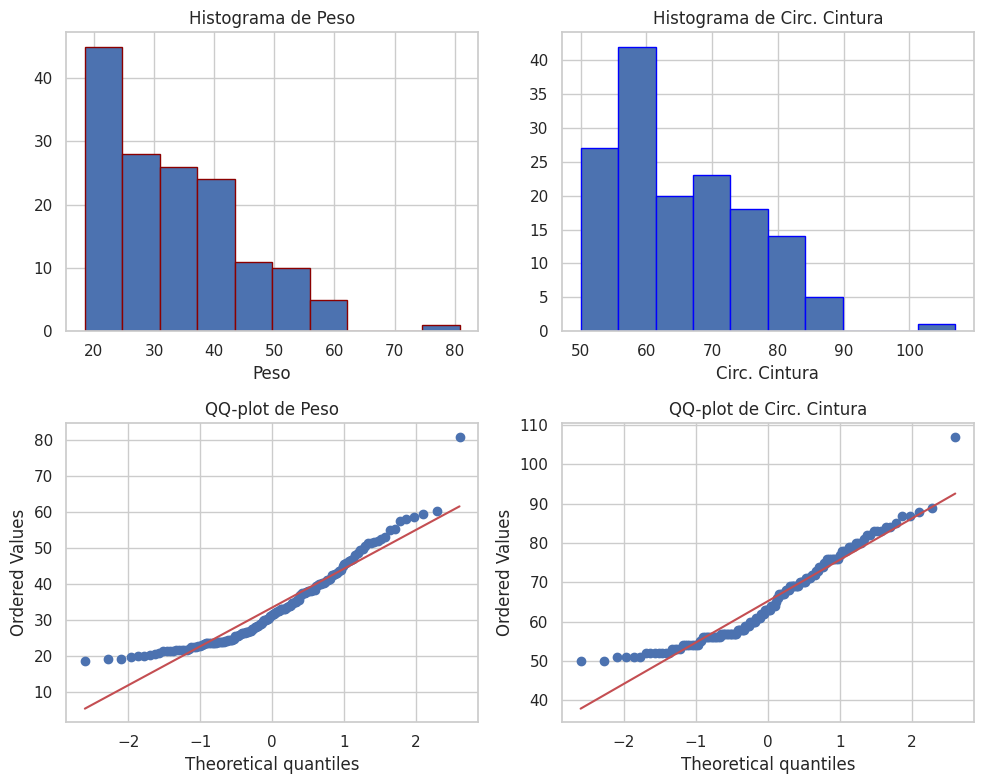

Shapiro-Wilk para PESO
ShapiroResult(statistic=np.float64(0.9154220555507404), pvalue=np.float64(1.0872005084173483e-07))
Shapiro-Wilk para CC
ShapiroResult(statistic=np.float64(0.9361829996470542), pvalue=np.float64(2.743513279449398e-06))


In [9]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(IMCinfantil["PESO"], bins=10, edgecolor="darkred")
axes[0, 0].set_title("Histograma de Peso")
axes[0, 0].set_xlabel("Peso")

axes[0, 1].hist(IMCinfantil["CC"], bins=10, edgecolor="blue")
axes[0, 1].set_title("Histograma de Circ. Cintura")
axes[0, 1].set_xlabel("Circ. Cintura")

stats.probplot(IMCinfantil["PESO"], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot de Peso")

stats.probplot(IMCinfantil["CC"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot de Circ. Cintura")

plt.tight_layout()
plt.show()

print("Shapiro-Wilk para PESO")
print(stats.shapiro(IMCinfantil["PESO"]))
print("Shapiro-Wilk para CC")
print(stats.shapiro(IMCinfantil["CC"]))


En ambos casos, si el valor-p es pequeño, se rechaza normalidad.

### Análisis de normalidad multivariada


En el archivo original se utilizaba el **test de Henze-Zirkler**.  
En Python, ese test no siempre está disponible por defecto en entornos básicos. Por eso, dejamos un bloque **opcional** que lo ejecuta si la librería `pingouin` está instalada. Si no lo está, el notebook sigue funcionando y muestra un mensaje aclaratorio.


In [ ]:
!pip install pingouin

In [13]:

peso_cc = IMCinfantil[["PESO", "CC"]].dropna().copy()

try:
    from pingouin import multivariate_normality
    hz_result = multivariate_normality(peso_cc, alpha=0.05)
    print(hz_result)
except ImportError:
    print(
        "No se pudo correr Henze-Zirkler porque la librería 'pingouin' no está instalada."
        "Si querés usarlo, instalá primero: pip install pingouin"
    )


HZResults(hz=np.float64(3.5203813035849643), pval=np.float64(3.523535718765999e-08), normal=False)


### Cálculo de correlación


Se calcula la correlación de **Pearson** entre las variables peso y circunferencia de la cintura.


In [14]:

print("Correlación de Pearson:", IMCinfantil["PESO"].corr(IMCinfantil["CC"], method="pearson"))
print(stats.pearsonr(IMCinfantil["PESO"], IMCinfantil["CC"]))


Correlación de Pearson: 0.9154241760210206
PearsonRResult(statistic=np.float64(0.9154241760210198), pvalue=np.float64(2.2788946689481988e-60))



Como puede no cumplirse el supuesto de normalidad bivariada, también calculamos la correlación de **Spearman**.


In [44]:

print("Correlación de Spearman:", IMCinfantil["PESO"].corr(IMCinfantil["CC"], method="spearman"))
print(stats.spearmanr(IMCinfantil["PESO"], IMCinfantil["CC"]))


Correlación de Spearman: 0.8985905180353414
SignificanceResult(statistic=np.float64(0.8985905180353414), pvalue=np.float64(8.23297123044661e-55))


### Correlograma

In [45]:

M = base_ninios.corr()
print("Matriz de correlación:")
display(M)

print("Matriz de varianzas y covarianzas:")
display(base_ninios.cov())


Matriz de correlación:


,EDAD,PESO,TALLA,IMC,CC
EDAD,1.0000,0.7341,0.8447,0.4485,0.6393
PESO,0.7341,1.0000,0.8694,0.8712,0.9154
TALLA,0.8447,0.8694,1.0000,0.5364,0.7256
IMC,0.4485,0.8712,0.5364,1.0000,0.8812
CC,0.6393,0.9154,0.7256,0.8812,1.0000


Matriz de varianzas y covarianzas:


,EDAD,PESO,TALLA,IMC,CC
EDAD,2.6510,13.3416,0.1702,2.4722,11.1739
PESO,13.3416,124.6024,1.2007,32.9243,109.6987
TALLA,0.1702,1.2007,0.0153,0.2247,0.9638
IMC,2.4722,32.9243,0.2247,11.4634,32.0309
CC,11.1739,109.6987,0.9638,32.0309,115.2475


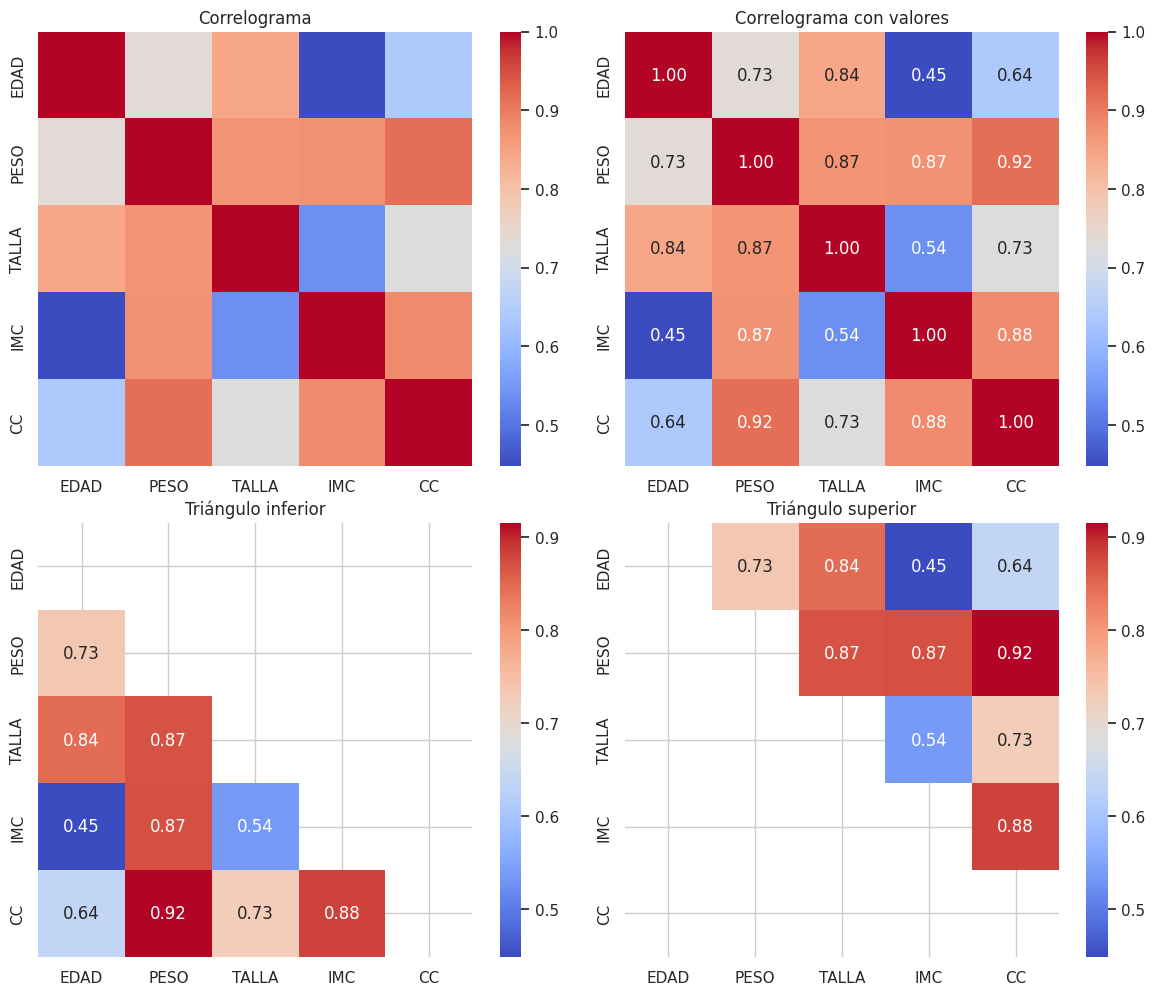

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(M, annot=False, cmap="coolwarm", square=True, ax=axes[0, 0])
axes[0, 0].set_title("Correlograma")

sns.heatmap(M, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[0, 1])
axes[0, 1].set_title("Correlograma con valores")

sns.heatmap(M, mask=np.triu(np.ones_like(M, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[1, 0])
axes[1, 0].set_title("Triángulo inferior")

sns.heatmap(M, mask=np.tril(np.ones_like(M, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[1, 1])
axes[1, 1].set_title("Triángulo superior")

plt.tight_layout()
plt.show()


## Ejemplo 2: Gorriones

Realizamos los diagramas de dispersión de las variables del dataset **gorriones.xlsx**.

In [20]:

gorr_github_url = "https://github.com/orcorsetti/MCD-Austral/raw/main/Regresion%20Avanzada/Regresion%20Lineal%20Simple/gorriones.xlsx"

try:
  gorr = pd.read_excel(gorr_github_url)
  print("Excel file loaded successfully from GitHub!")
  display(gorr.head())
  gorr = pd.DataFrame(gorr)
  print(gorr.shape)
  print(gorr.columns.tolist())
  display(gorr.head())

except Exception as e:
    print(f"Error loading Excel file from GitHub: {e}")
    print("Please ensure the URL is correct and points to the raw Excel file.")
    # Assign an empty DataFrame or handle the error appropriately if loading fails
    gorr = pd.DataFrame() # Assign an empty DataFrame to avoid NameError if the try block fails



Excel file loaded successfully from GitHub!


,Pájaro,Largo,Alas,Cabeza,Pata,Cuerpo,Sobrevida
0,1,156,245,31.6000,18.5000,20.5000,1
1,2,154,240,30.4000,17.9000,19.6000,1
2,3,153,240,31.0000,18.4000,20.6000,1
3,4,153,236,30.9000,17.7000,20.2000,1
4,5,155,243,31.5000,18.6000,20.3000,1


(49, 7)
['Pájaro', 'Largo', 'Alas', 'Cabeza', 'Pata', 'Cuerpo', 'Sobrevida']


,Pájaro,Largo,Alas,Cabeza,Pata,Cuerpo,Sobrevida
0,1,156,245,31.6000,18.5000,20.5000,1
1,2,154,240,30.4000,17.9000,19.6000,1
2,3,153,240,31.0000,18.4000,20.6000,1
3,4,153,236,30.9000,17.7000,20.2000,1
4,5,155,243,31.5000,18.6000,20.3000,1


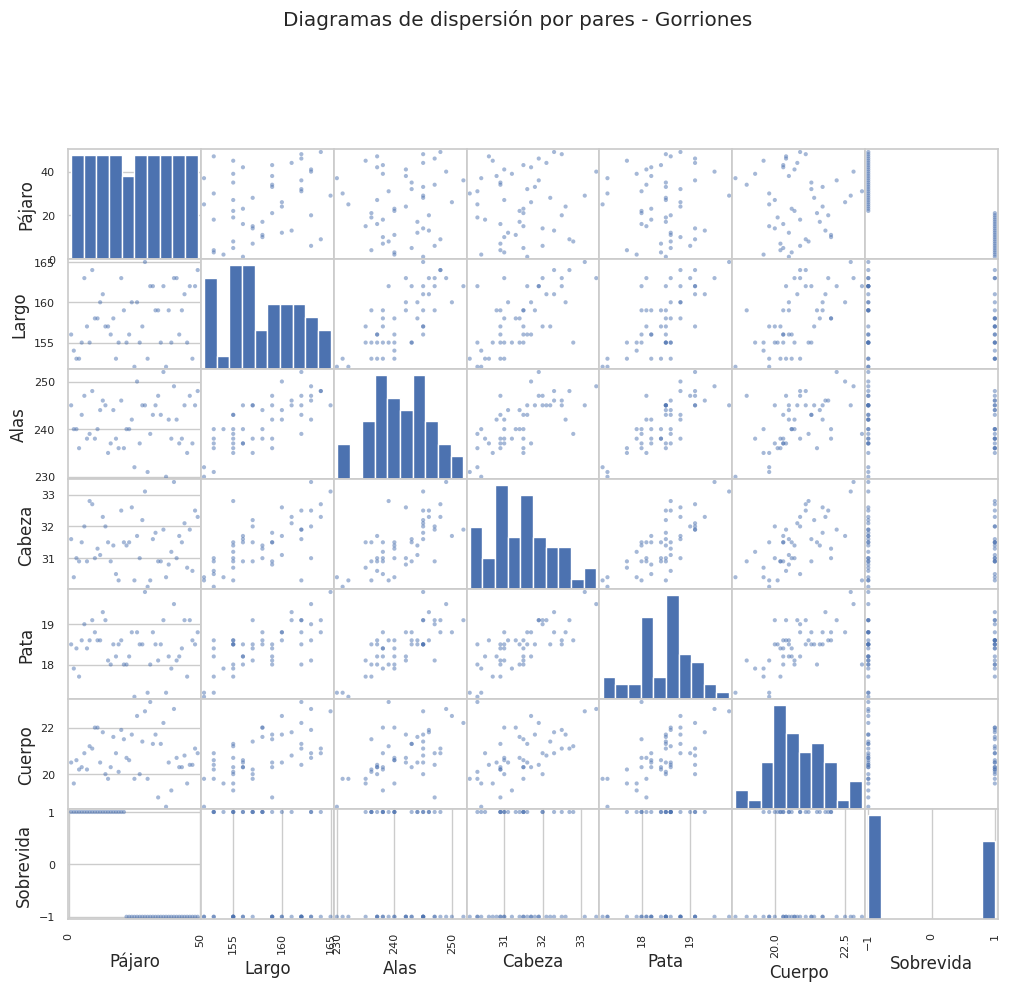

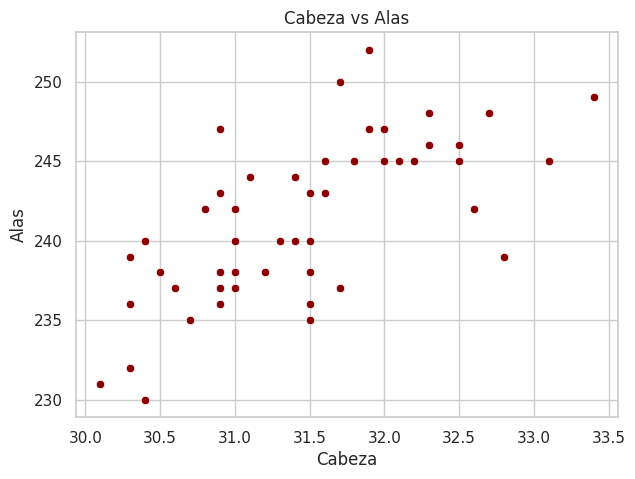

In [21]:

pd.plotting.scatter_matrix(gorr, figsize=(12, 10), diagonal='hist')
plt.suptitle("Diagramas de dispersión por pares - Gorriones", y=1.02)
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=gorr, x="Cabeza", y="Alas", color="darkred")
plt.title("Cabeza vs Alas")
plt.show()


### Análisis de normalidad de las variables - Test de Shapiro Wilk

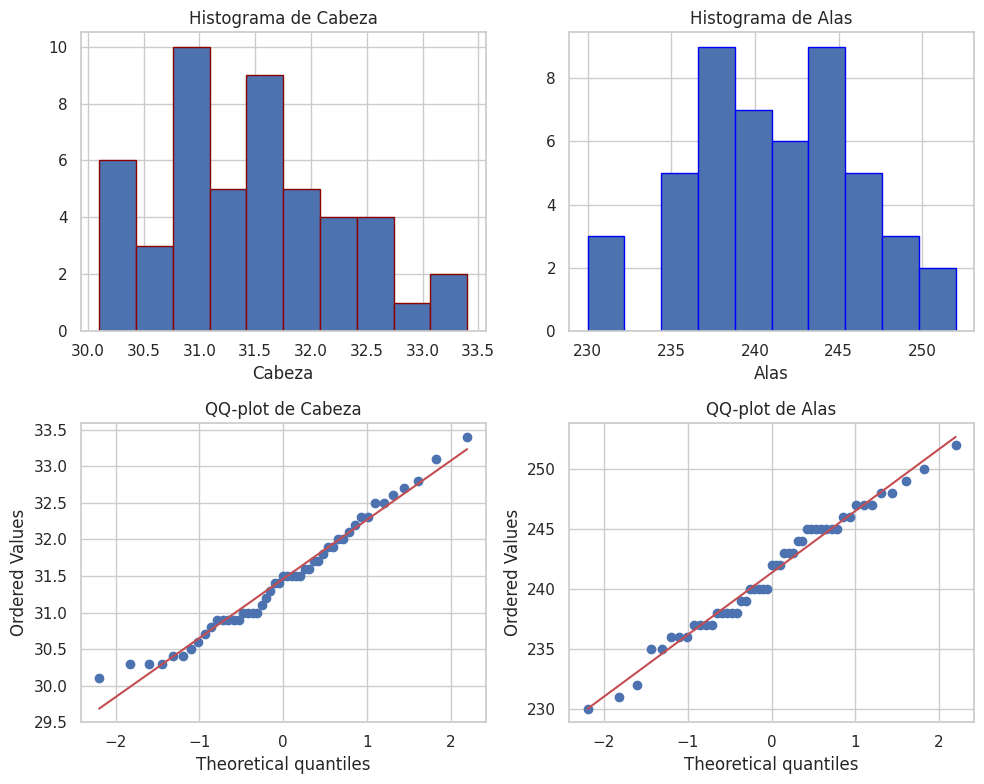

Shapiro-Wilk para Cabeza
ShapiroResult(statistic=np.float64(0.9737509365857515), pvalue=np.float64(0.3391274828616082))
Shapiro-Wilk para Alas
ShapiroResult(statistic=np.float64(0.9788787200741089), pvalue=np.float64(0.5191927887941887))


In [23]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(gorr["Cabeza"], bins=10, edgecolor="darkred")
axes[0, 0].set_title("Histograma de Cabeza")
axes[0, 0].set_xlabel("Cabeza")

axes[0, 1].hist(gorr["Alas"], bins=10, edgecolor="blue")
axes[0, 1].set_title("Histograma de Alas")
axes[0, 1].set_xlabel("Alas")

stats.probplot(gorr["Cabeza"], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot de Cabeza")

stats.probplot(gorr["Alas"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot de Alas")

plt.tight_layout()
plt.show()

print("Shapiro-Wilk para Cabeza")
print(stats.shapiro(gorr["Cabeza"]))
print("Shapiro-Wilk para Alas")
print(stats.shapiro(gorr["Alas"]))


### Análisis de normalidad multivariada

In [24]:

cabeza_alas = gorr[["Cabeza", "Alas"]].dropna().copy()

try:
    from pingouin import multivariate_normality
    hz_result_gorr = multivariate_normality(cabeza_alas, alpha=0.05)
    print(hz_result_gorr)
except ImportError:
    print(
        "No se pudo correr Henze-Zirkler porque la librería 'pingouin' no está instalada."
        "Si querés usarlo, instalá primero: pip install pingouin"
    )


HZResults(hz=np.float64(0.45646350594689716), pval=np.float64(0.5389817740231202), normal=True)


### Cálculo de correlación

Se calcula la correlación de Pearson entre la longitud de la cabeza y la longitud de las alas.

In [25]:

print("Correlación de Pearson:", gorr["Cabeza"].corr(gorr["Alas"], method="pearson"))
print(stats.pearsonr(gorr["Cabeza"], gorr["Alas"]))


Correlación de Pearson: 0.673741089393143
PearsonRResult(statistic=np.float64(0.673741089393143), pvalue=np.float64(1.123000087318036e-07))


## Modelos lineales

Supongamos que queremos estudiar la longitud del largo de los gorriones en función de las otras variables a través de un modelo lineal.

In [26]:

model_gorr1 = smf.ols("Largo ~ Alas", data=gorr).fit()
model_gorr2 = smf.ols("Largo ~ Cabeza", data=gorr).fit()
model_gorr3 = smf.ols("Largo ~ Pata", data=gorr).fit()
model_gorr4 = smf.ols("Largo ~ Cuerpo", data=gorr).fit()
model_gorr5 = smf.ols("Largo ~ Alas + Pata", data=gorr).fit()
model_gorr = smf.ols("Largo ~ Alas + Cabeza + Pata + Cuerpo", data=gorr).fit()

print(model_gorr1.summary())
print(model_gorr2.summary())
print(model_gorr3.summary())
print(model_gorr4.summary())
print(model_gorr5.summary())
print(model_gorr.summary())


                            OLS Regression Results                            
Dep. Variable:                  Largo   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     55.21
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.82e-09
Time:                        23:57:05   Log-Likelihood:                -113.49
No. Observations:                  49   AIC:                             231.0
Df Residuals:                      47   BIC:                             234.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.0852     17.216      1.748      0.0

## Comparación de modelos

### Usando ANOVA

In [46]:

print(anova_lm(model_gorr1, model_gorr5))
print(anova_lm(model_gorr3, model_gorr5))
print(anova_lm(model_gorr2, model_gorr))
print(anova_lm(model_gorr1, model_gorr))
print(anova_lm(model_gorr3, model_gorr))
print(anova_lm(model_gorr5, model_gorr))


   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0   47.0000 294.7401   0.0000      NaN    NaN     NaN
1   46.0000 274.2696   1.0000  20.4705 3.4333  0.0703
   df_resid      ssr  df_diff  ss_diff       F  Pr(>F)
0   47.0000 344.8764   0.0000      NaN     NaN     NaN
1   46.0000 274.2696   1.0000  70.6068 11.8420  0.0012
   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0   47.0000 360.2337   0.0000      NaN    NaN     NaN
1   44.0000 235.9050   3.0000 124.3287 7.7298  0.0003
   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0   47.0000 294.7401   0.0000      NaN    NaN     NaN
1   44.0000 235.9050   3.0000  58.8351 3.6579  0.0194
   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0   47.0000 344.8764   0.0000      NaN    NaN     NaN
1   44.0000 235.9050   3.0000 108.9714 6.7750  0.0007
   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0   46.0000 274.2696   0.0000      NaN    NaN     NaN
1   44.0000 235.9050   2.0000  38.3646 3.5778  0.0363


### Usando AIC y BIC

In [28]:

comparacion_modelos = pd.DataFrame({
    "Modelo": ["model_gorr1", "model_gorr2", "model_gorr3", "model_gorr5", "model_gorr"],
    "AIC": [model_gorr1.aic, model_gorr2.aic, model_gorr3.aic, model_gorr5.aic, model_gorr.aic],
    "BIC": [model_gorr1.bic, model_gorr2.bic, model_gorr3.bic, model_gorr5.bic, model_gorr.bic]
})

comparacion_modelos


,Modelo,AIC,BIC
0,model_gorr1,230.9754,234.7590
1,model_gorr2,240.8077,244.5913
2,model_gorr3,238.6729,242.4565
3,model_gorr5,229.4483,235.1237
4,model_gorr,226.0648,235.5239


## Estimación de coeficientes y recta de regresión

### Tests tipo Wald


En `statsmodels`, los contrastes tipo Wald se pueden hacer con `wald_test`.  
Los nombres de coeficientes incluyen el intercepto como `Intercept`.


In [29]:

# Comparación conjunta de Cabeza y Pata en el modelo múltiple
print(model_gorr.wald_test("Cabeza = 0, Pata = 0"))

# Comparación conjunta de Alas y Cabeza en el modelo múltiple
print(model_gorr.wald_test("Alas = 0, Cabeza = 0"))

# Tests individuales
print(model_gorr.wald_test("Alas = 0"))
print(model_gorr1.wald_test("Alas = 0"))
print(model_gorr.wald_test("Cabeza = 0"))
print(model_gorr2.wald_test("Cabeza = 0"))
print(model_gorr.wald_test("Pata = 0"))
print(model_gorr3.wald_test("Pata = 0"))
print(model_gorr.wald_test("Cuerpo = 0"))
print(model_gorr4.wald_test("Cuerpo = 0"))


<F test: F=array([[1.60267417]]), p=0.21288856527591496, df_denom=44, df_num=2>
<F test: F=array([[6.65582451]]), p=0.0029827371370505897, df_denom=44, df_num=2>
<F test: F=array([[8.7003453]]), p=0.005080153738758482, df_denom=44, df_num=1>
<F test: F=array([[55.21221998]]), p=1.8240790618870944e-09, df_denom=47, df_num=1>
<F test: F=array([[2.21481989]]), p=0.14382359222225424, df_denom=44, df_num=1>
<F test: F=array([[36.62915663]]), p=2.2439047018274698e-07, df_denom=47, df_num=1>
<F test: F=array([[0.04718718]]), p=0.8290363075755441, df_denom=44, df_num=1>
<F test: F=array([[40.35314694]]), p=7.865785085680898e-08, df_denom=47, df_num=1>
<F test: F=array([[4.21394445]]), p=0.04606920140372807, df_denom=44, df_num=1>
<F test: F=array([[27.15305935]]), p=4.1094387531601115e-06, df_denom=47, df_num=1>



**Observación:** cuando una variable resulta significativa en un modelo simple pero no en un modelo múltiple, una explicación frecuente es la presencia de colinealidad o solapamiento de información entre predictores.


### Intervalos de confianza

In [30]:
model_gorr.conf_int()

,0,1
Intercept,-5.5416,62.0274
Alas,0.0994,0.5280
Cabeza,-0.3491,2.3205
Pata,-2.0854,2.5893
Cuerpo,0.0161,1.7488


### Gráfico de recta de regresión

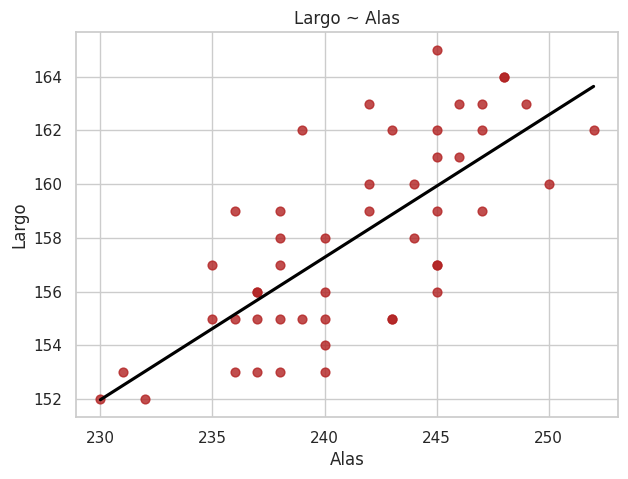

In [31]:

plt.figure(figsize=(7, 5))
sns.regplot(data=gorr, x="Alas", y="Largo", scatter_kws={"color": "firebrick", "s": 40}, line_kws={"color": "black"}, ci=None)
plt.title("Largo ~ Alas")
plt.xlabel("Alas")
plt.ylabel("Largo")
plt.show()


## Predicción e intervalos de confianza

Genero nuevos datos en el rango de X.

In [32]:
nuevosdatos = np.linspace(gorr["Alas"].min(), gorr["Alas"].max(), 100)
nuevosdatos[:5]

array([230.        , 230.22222222, 230.44444444, 230.66666667,
       230.88888889])

Predigo valores de `Largo` para nuevos valores de `Alas`.

In [33]:

new_df = pd.DataFrame({"Alas": nuevosdatos})
predicciones = model_gorr1.predict(new_df)
predicciones.head()


,0
0,151.9769
1,152.0947
2,152.2125
3,152.3302
4,152.4480


Se puede predecir por fuera del rango observado, aunque la confiabilidad puede ser menor.

In [34]:
model_gorr1.predict(pd.DataFrame({"Alas": [280]}))

,0
0,178.4751


Predigo `Y` y agrego su intervalo de confianza para cada uno de los nuevos datos generados.

In [35]:

pred_summary = model_gorr1.get_prediction(new_df).summary_frame(alpha=0.05)
pred_summary.head()


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,151.9769,0.8835,150.1995,153.7543,146.6348,157.3191
1,152.0947,0.8690,150.3464,153.8430,146.7622,157.4273
2,152.2125,0.8546,150.4932,153.9318,146.8894,157.5356
3,152.3302,0.8403,150.6399,154.0206,147.0164,157.6441
4,152.4480,0.8259,150.7864,154.1096,147.1433,157.7528


Armo el gráfico con la recta ajustada y las curvas de intervalos de confianza.

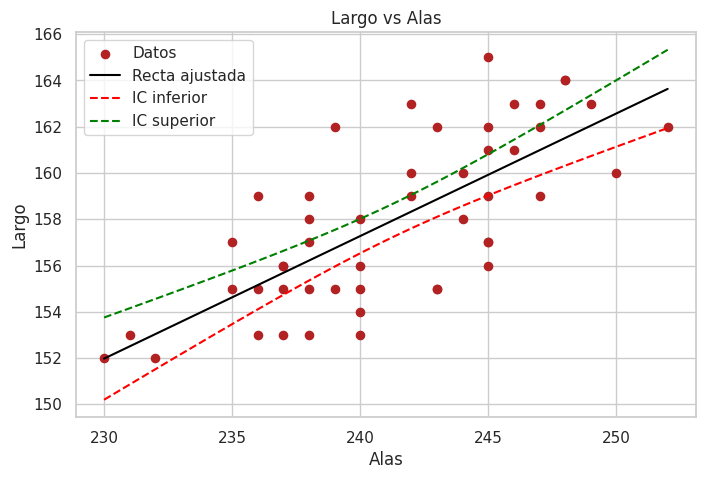

In [36]:

plt.figure(figsize=(8, 5))
plt.scatter(gorr["Alas"], gorr["Largo"], color="firebrick", s=35, label="Datos")
plt.plot(new_df["Alas"], pred_summary["mean"], color="black", label="Recta ajustada")
plt.plot(new_df["Alas"], pred_summary["mean_ci_lower"], linestyle="--", color="red", label="IC inferior")
plt.plot(new_df["Alas"], pred_summary["mean_ci_upper"], linestyle="--", color="green", label="IC superior")
plt.xlabel("Alas")
plt.ylabel("Largo")
plt.title("Largo vs Alas")
plt.legend()
plt.show()


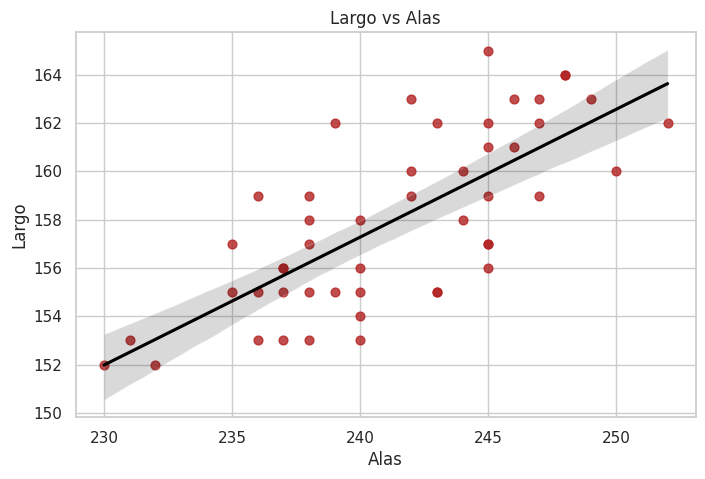

In [37]:

# Alternativa con seaborn, mostrando banda de confianza al 95%
plt.figure(figsize=(8, 5))
sns.regplot(data=gorr, x="Alas", y="Largo", scatter_kws={"color": "firebrick", "s": 40}, line_kws={"color": "black"}, ci=95)
plt.title("Largo vs Alas")
plt.show()


## Validación de supuestos y análisis diagnóstico

### Análisis de normalidad de los residuos - Test de Shapiro Wilk

In [38]:

gorr2 = gorr.copy()
gorr2["prediccion"] = model_gorr1.fittedvalues
gorr2["residuos"] = model_gorr1.resid

display(gorr2.head())


,Pájaro,Largo,Alas,Cabeza,Pata,Cuerpo,Sobrevida,prediccion,residuos
0,1,156,245,31.6000,18.5000,20.5000,1,159.9264,-3.9264
1,2,154,240,30.4000,17.9000,19.6000,1,157.2766,-3.2766
2,3,153,240,31.0000,18.4000,20.6000,1,157.2766,-4.2766
3,4,153,236,30.9000,17.7000,20.2000,1,155.1567,-2.1567
4,5,155,243,31.5000,18.6000,20.3000,1,158.8665,-3.8665


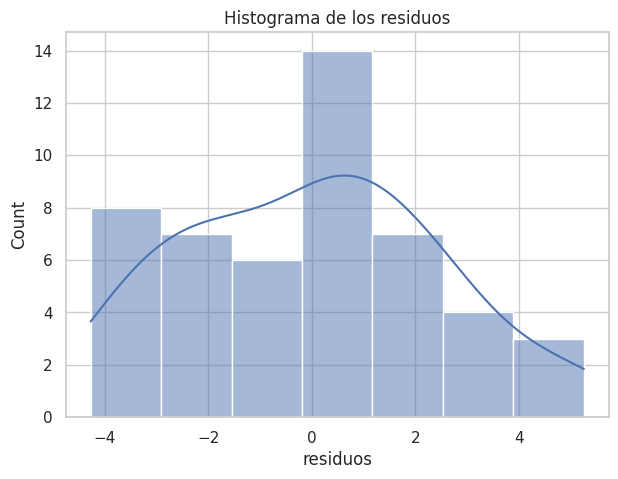

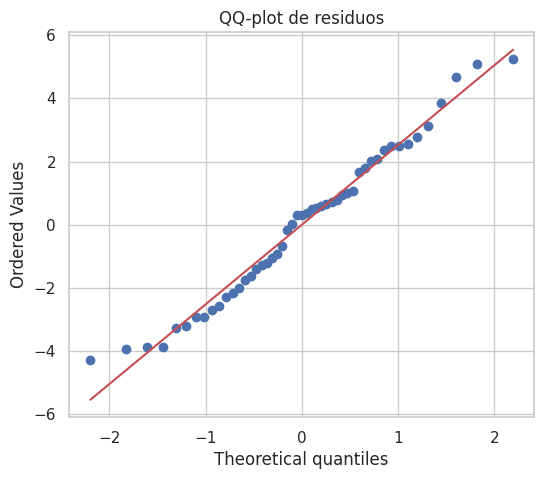

ShapiroResult(statistic=np.float64(0.9737532202877245), pvalue=np.float64(0.33919532487548937))


In [39]:

plt.figure(figsize=(7, 5))
sns.histplot(gorr2["residuos"], kde=True)
plt.title("Histograma de los residuos")
plt.show()

fig = plt.figure(figsize=(6, 5))
stats.probplot(model_gorr1.resid, dist="norm", plot=plt)
plt.title("QQ-plot de residuos")
plt.show()

print(stats.shapiro(model_gorr1.resid))


### Gráfico de análisis de homocedasticidad

Si se observa algún patrón visual claro, podría cuestionarse el supuesto de homocedasticidad.

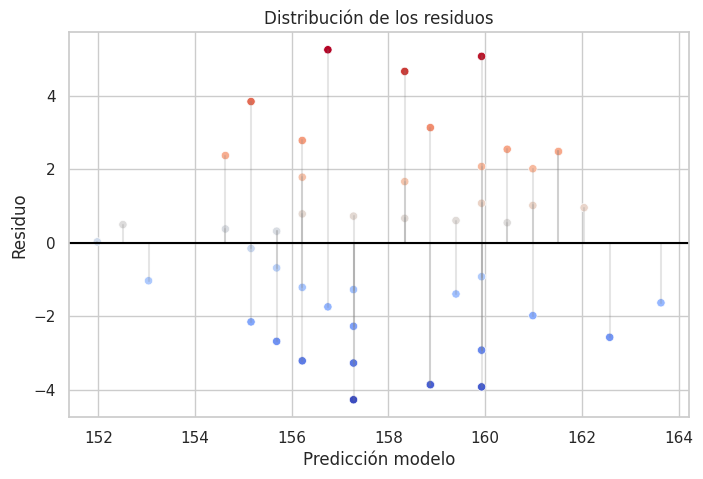

In [40]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=gorr2, x="prediccion", y="residuos", hue="residuos", palette="coolwarm", legend=False)
for _, row in gorr2.iterrows():
    plt.plot([row["prediccion"], row["prediccion"]], [0, row["residuos"]], color="gray", alpha=0.2)
plt.axhline(0, color="black")
plt.title("Distribución de los residuos")
plt.xlabel("Predicción modelo")
plt.ylabel("Residuo")
plt.show()


### Test de Breusch-Pagan

Analizamos si los residuos tienen varianza constante (homocedasticidad).

In [41]:

bp_test = het_breuschpagan(model_gorr1.resid, model_gorr1.model.exog)
bp_labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]
print(dict(zip(bp_labels, bp_test)))


{'LM Statistic': np.float64(0.7039743694134185), 'LM-Test p-value': np.float64(0.40145146232512574), 'F-Statistic': np.float64(0.685083191223839), 'F-Test p-value': np.float64(0.41202487871802274)}


Si el valor-p no es pequeño, no se rechaza homocedasticidad.

### Gráfico de análisis de independencia de las observaciones

Analizamos los residuos según el orden de las observaciones para ver si se observa dependencia.

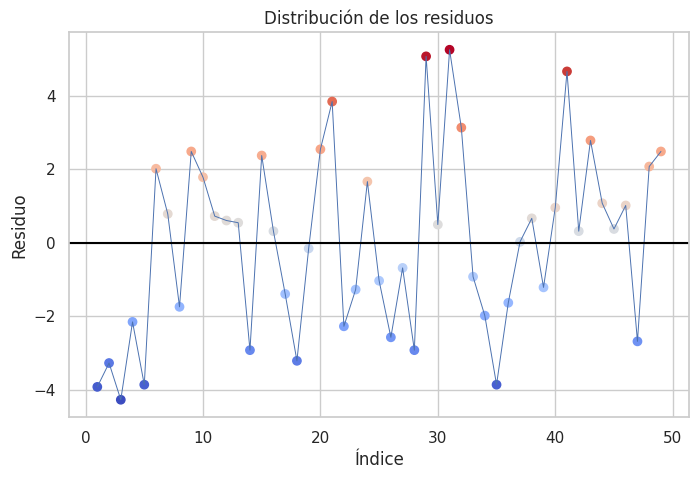

In [42]:

plt.figure(figsize=(8, 5))
plt.scatter(np.arange(1, len(gorr2) + 1), gorr2["residuos"], c=gorr2["residuos"], cmap="coolwarm")
plt.plot(np.arange(1, len(gorr2) + 1), gorr2["residuos"], linewidth=0.7)
plt.axhline(0, color="black")
plt.title("Distribución de los residuos")
plt.xlabel("Índice")
plt.ylabel("Residuo")
plt.show()


No se detecta un patrón si los puntos no muestran tendencia ni estructura clara.

### Test de Durbin-Watson

Analizamos autocorrelación de los residuos. Valores cercanos a 2 suelen indicar ausencia de autocorrelación.

In [43]:
print("Durbin-Watson:", durbin_watson(model_gorr1.resid))

Durbin-Watson: 1.4722987777628325
